In [1]:

import seisbench.models as sbm
# list pretrained
names = sbm.PhaseNet.list_pretrained()
print('list_pretrained:', names)
# try loading one and inspect attributes
m = sbm.PhaseNet.from_pretrained(names[0] if names else 'stead')
attrs = [a for a in dir(m) if not a.startswith('_')]
for a in ['docstring', 'name', 'weights_docstring', 'version', 'model_args', 'default_args']:
    if hasattr(m, a):
        print(a, ':', getattr(m, a))
# common seisbench pattern
for a in ['weights_version', 'train_dataset', 'training_dataset']:
    if hasattr(m, a):
        print(a, getattr(m, a))


list_pretrained: ['diting', 'ethz', 'geofon', 'instance', 'iquique', 'jma', 'jma_wc', 'lendb', 'neic', 'obs', 'original', 'phasenet_sn', 'pisdl', 'scedc', 'stead', 'volpick']
name : PhaseNet
weights_docstring : Model trained on the DiTing dataset, a large-scale Chinese seismic benchmark dataset.
For models fine-tuned on individual regions in China, please see: https://github.com/JUNZHU-SEIS/USTC-Pickers
If you use this model, please reference: Zhu J, Li ZF and Fang LH (2023). USTC-Pickers: a Unified Set of seismic phase pickers Transfer learned for China. Earthq Sci 36(2): 95–112, doi: 10.1016/j.eqs.2023.03.001
default_args : {'P_threshold': 0.3, 'S_threshold': 0.3, 'blinding': [250, 250]}
weights_version 2


#### Preparing high quality training dataset for retraining PhaseNet from scratch on the PNW earthquakes, explosions and surface events

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [20]:
#data files
file_noise="/data/whd02/niyiyu_data/PNWML/noise/waveforms.hdf5";
file_comcat=  "/data/whd02/niyiyu_data/PNWML/comcat/waveforms.hdf5";
file_exotic="/data/whd02/niyiyu_data/PNWML/exotic/waveforms.hdf5";

# metadata
# accessing the comcat metadata
comcat_metadata = pd.read_csv("/data/whd02/niyiyu_data/PNWML/comcat/metadata.csv")
# comcat_metadata = pd.read_csv("/data/whd01/yiyu_data/PNWML/comcat_metadata.csv")

# accessing the exotic metadata
exotic_metadata = pd.read_csv("/data/whd02/niyiyu_data/PNWML/exotic/metadata.csv")
# exotic_metadata = pd.read_csv("/data/whd01/yiyu_data/PNWML/exotic_metadata.csv")

# accessing the data files
metadata_noise = pd.read_csv("/data/whd02/niyiyu_data/PNWML/noise/metadata.csv")
# metadata_noise = pd.read_csv("/data/whd01/yiyu_data/PNWML/noise_metadata.csv")

# creating individual data frames for each class

cat_exp = comcat_metadata[comcat_metadata['source_type'] == 'explosion']
cat_eq = comcat_metadata[comcat_metadata['source_type'] == 'earthquake']
cat_su = exotic_metadata[exotic_metadata['source_type'] == 'surface event']
cat_noise = metadata_noise
cat_noise['event_id'] = [cat_noise['trace_start_time'][i]+'_noise' for i in range(len(cat_noise))]

In [21]:
print("Columns in cat_eq:")
print(cat_eq.columns.tolist())

Columns in cat_eq:
['event_id', 'source_origin_time', 'source_latitude_deg', 'source_longitude_deg', 'source_type', 'source_depth_km', 'preferred_source_magnitude', 'preferred_source_magnitude_type', 'preferred_source_magnitude_uncertainty', 'source_depth_uncertainty_km', 'source_horizontal_uncertainty_km', 'station_network_code', 'station_channel_code', 'station_code', 'station_location_code', 'station_latitude_deg', 'station_longitude_deg', 'station_elevation_m', 'trace_name', 'trace_sampling_rate_hz', 'trace_start_time', 'trace_S_arrival_sample', 'trace_P_arrival_sample', 'trace_S_arrival_uncertainty_s', 'trace_P_arrival_uncertainty_s', 'trace_P_polarity', 'trace_S_onset', 'trace_P_onset', 'trace_snr_db', 'source_type_pnsn_label', 'source_local_magnitude', 'source_local_magnitude_uncertainty', 'source_duration_magnitude', 'source_duration_magnitude_uncertainty', 'source_hand_magnitude', 'trace_missing_channel', 'trace_has_offset']


# 1. Seismological Fundamentals First
# P-S Time (source-receiver distance proxy)

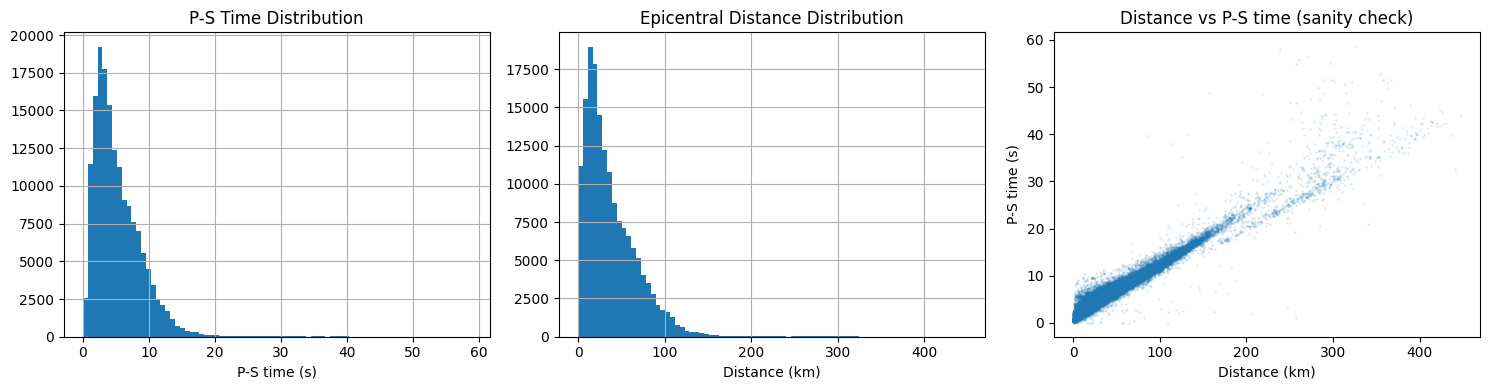

In [22]:
import seisbench.data as sbd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from obspy.geodetics import degrees2kilometers

# Load the dataset
pnw = file_comcat
meta = cat_eq.copy()

# Compute P-S time in seconds (at 100 Hz)
meta['ps_time_s'] = (meta['trace_S_arrival_sample'] - meta['trace_P_arrival_sample']) / 100.0

# Compute epicentral distance
from obspy.geodetics.base import gps2dist_azimuth
meta['epi_dist_km'] = meta.apply(
    lambda r: gps2dist_azimuth(
        r['source_latitude_deg'], r['source_longitude_deg'],
        r['station_latitude_deg'], r['station_longitude_deg']
    )[0] / 1000.0, axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
meta['ps_time_s'].hist(bins=80, ax=axes[0])
axes[0].set_xlabel('P-S time (s)')
axes[0].set_title('P-S Time Distribution')

meta['epi_dist_km'].hist(bins=80, ax=axes[1])
axes[1].set_xlabel('Distance (km)')
axes[1].set_title('Epicentral Distance Distribution')

axes[2].scatter(meta['epi_dist_km'], meta['ps_time_s'], alpha=0.1, s=1)
axes[2].set_xlabel('Distance (km)')
axes[2].set_ylabel('P-S time (s)')
axes[2].set_title('Distance vs P-S time (sanity check)')
plt.tight_layout()

In [23]:
# ── Theoretical conversion ───────────────────────────────────────────────────
Vp = 6.0   # km/s  — typical PNW crustal P velocity
Vs = 3.5   # km/s  — typical PNW crustal S velocity

slowness_diff = (1/Vs) - (1/Vp)          # s/km
km_per_ps_sec = 1.0 / slowness_diff       # km per second of P-S time

print("=== Wadati relationship ===")
print(f"  (1/Vs) - (1/Vp) = (1/{Vs}) - (1/{Vp})")
print(f"                   = {1/Vs:.4f} - {1/Vp:.4f}")
print(f"                   = {slowness_diff:.4f} s/km")
print(f"  → 1 s of P-S time ≈ {km_per_ps_sec:.1f} km")
print()

# ── Verify against your data ─────────────────────────────────────────────────
# The empirical slope from your scatter plot should be close to km_per_ps_sec
from scipy import stats

mask = (
    meta['ps_time_s'].between(0.5, 60) &
    meta['epi_dist_km'].between(1, 450)
)
clean = meta[mask].dropna(subset=['ps_time_s', 'epi_dist_km'])

slope, intercept, r_value, _, std_err = stats.linregress(
    clean['ps_time_s'],
    clean['epi_dist_km']
)

print("=== Empirical fit from your scatter plot ===")
print(f"  slope (empirical) : {slope:.2f} km/s")
print(f"  slope (theory)    : {km_per_ps_sec:.2f} km/s")
print(f"  difference        : {abs(slope - km_per_ps_sec):.2f} km/s  "
      f"({abs(slope - km_per_ps_sec)/km_per_ps_sec*100:.1f}%)")
print(f"  R²                : {r_value**2:.4f}")
print()

# ── Now correctly translate the histogram peak ───────────────────────────────
print("=== P-S time percentiles → distance (corrected) ===")
for q in [0.25, 0.50, 0.75, 0.90]:
    ps_q   = clean['ps_time_s'].quantile(q)
    # Use empirical slope — more honest than assuming a 1D velocity model
    dist_theory   = ps_q / slowness_diff
    dist_empirical = slope * ps_q + intercept
    print(f"  {int(q*100)}th pct: P-S = {ps_q:.1f}s  "
          f"→ theory: {dist_theory:.0f} km  "
          f"| empirical: {dist_empirical:.0f} km")

=== Wadati relationship ===
  (1/Vs) - (1/Vp) = (1/3.5) - (1/6.0)
                   = 0.2857 - 0.1667
                   = 0.1190 s/km
  → 1 s of P-S time ≈ 8.4 km

=== Empirical fit from your scatter plot ===
  slope (empirical) : 8.59 km/s
  slope (theory)    : 8.40 km/s
  difference        : 0.19 km/s  (2.2%)
  R²                : 0.9638

=== P-S time percentiles → distance (corrected) ===
  25th pct: P-S = 2.7s  → theory: 22 km  | empirical: 16 km
  50th pct: P-S = 4.4s  → theory: 37 km  | empirical: 31 km
  75th pct: P-S = 7.2s  → theory: 61 km  | empirical: 55 km
  90th pct: P-S = 10.0s  → theory: 84 km  | empirical: 79 km


## What These Plots Tell You
### Plot 1 — P-S Time Distribution (left)
The distribution is severely right-skewed with a sharp peak at 2–5 seconds and a long tail extending to ~60s. This means:

The vast majority of recordings are very nearby events (local, < 50 km away)
Events beyond ~20s P-S time (> ~150 km) are severely underrepresented
There's a suspicious bimodal-looking bump around 1–3s — this is likely the dominance of very close small-magnitude events that are numerous in the Gutenberg-Richter distribution



Training implication: If you train PhaseNet on this raw distribution, the model will be heavily optimized for short P-S windows. It will likely fail or perform poorly on events at regional distances (> 100 km) because it has rarely seen those waveform patterns.



### Plot 2 — Epicentral Distance Distribution (middle)
Mirrors Plot 1 directly (as expected from the sanity check). The peak is at < 30 km with very few events beyond 200 km. This confirms:

The PNW network is dense and local — it records mostly nearby small earthquakes very well
The distribution is a classic network coverage artifact: stations are clustered in populated areas of Washington/Oregon, so most recorded events are close
There's essentially no data beyond 400 km


### Plot 3 — Distance vs P-S Time Scatter (right)
This is the most physically informative. The tight linear relationship is exactly what you expect from P-S time ≈ distance / Vp_eff (a simple velocity model). The scatter around the line is physical — it reflects:

Real crustal velocity variations across the PNW (Cascadia subduction zone, volcanic arc, back-arc)
Different source depths (deeper events have longer paths)
Some scatter from pick uncertainty

The relationship looks clean and physically consistent — no major outliers cloud of bad picks at implausible values, which is a good data quality indicator. The slight fan-shape widening at larger distances is also physically expected (more path variability).


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Step 1: Make sure ps_time_s exists ──────────────────────────────────────
# This depends on trace_P_arrival_sample and trace_S_arrival_sample
# being numeric — coerce them first

meta['trace_P_arrival_sample'] = pd.to_numeric(
    meta['trace_P_arrival_sample'], errors='coerce'
)
meta['trace_S_arrival_sample'] = pd.to_numeric(
    meta['trace_S_arrival_sample'], errors='coerce'
)

# Compute P-S time in seconds (sampling rate = 100 Hz)
meta['ps_time_s'] = (
    meta['trace_S_arrival_sample'] - meta['trace_P_arrival_sample']
) / 100.0

# Sanity check before proceeding
n_missing = meta['ps_time_s'].isna().sum()
n_negative = (meta['ps_time_s'] < 0).sum()
print(f"ps_time_s computed: {len(meta):,} traces")
print(f"  NaN (missing P or S pick) : {n_missing:,}")
print(f"  Negative (S before P)     : {n_negative:,}  ← physical impossibility, will be dropped")
print(f"  Valid                     : {(meta['ps_time_s'] > 0).sum():,}")
print()

# Drop rows where ps_time_s is invalid
meta = meta[meta['ps_time_s'] > 0].copy()

# ── Step 2: Create ps_bin ────────────────────────────────────────────────────
bins   = [0, 2, 5, 10, 20, 40, 65]
labels = [
    '<2s (very local)',
    '2-5s (local)',
    '5-10s (near-regional)',
    '10-20s (regional)',
    '20-40s (far-regional)',
    '>40s (teleseismic fringe)'
]

meta['ps_bin'] = pd.cut(
    meta['ps_time_s'],
    bins   = bins,
    labels = labels
)

# Confirm it was created
print(f"ps_bin column created: {meta['ps_bin'].notna().sum():,} labelled traces")
print(f"ps_bin NaN (outside bin range): {meta['ps_bin'].isna().sum():,}")
print()

# ── Step 3: Now safely compute bin counts ───────────────────────────────────
bin_counts = meta['ps_bin'].value_counts().sort_index()

print("=== Dataset inventory ===")
print(f"Total traces: {len(meta):,}")
print()
for bin_label, count in bin_counts.items():
    pct = count / len(meta) * 100
    bar = '█' * int(pct / 2)
    print(f"  {str(bin_label):<35} : {count:>6,}  ({pct:4.1f}%)  {bar}")

print()
print(f"Imbalance ratio: {bin_counts.max()/bin_counts.min():.0f}x")

ps_time_s computed: 163,064 traces
  NaN (missing P or S pick) : 0
  Negative (S before P)     : 0  ← physical impossibility, will be dropped
  Valid                     : 163,064

ps_bin column created: 163,064 labelled traces
ps_bin NaN (outside bin range): 0

=== Dataset inventory ===
Total traces: 163,064

  <2s (very local)                    : 25,295  (15.5%)  ███████
  2-5s (local)                        : 67,037  (41.1%)  ████████████████████
  5-10s (near-regional)               : 54,459  (33.4%)  ████████████████
  10-20s (regional)                   : 15,170  ( 9.3%)  ████
  20-40s (far-regional)               :  1,007  ( 0.6%)  
  >40s (teleseismic fringe)           :     96  ( 0.1%)  

Imbalance ratio: 698x


## 2. Magnitude Distribution

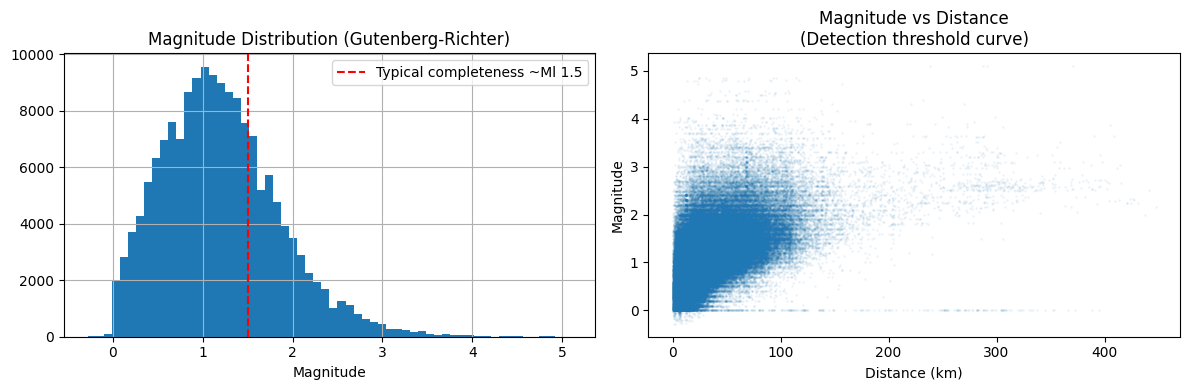

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
meta['preferred_source_magnitude'].hist(bins=60, ax=axes[0])
axes[0].set_xlabel('Magnitude')
axes[0].set_title('Magnitude Distribution (Gutenberg-Richter)')
axes[0].axvline(1.5, color='r', linestyle='--', label='Typical completeness ~Ml 1.5')
axes[0].legend()

# 2D: magnitude vs distance — critical for understanding SNR coverage
axes[1].scatter(meta['epi_dist_km'], meta['preferred_source_magnitude'],
                alpha=0.05, s=1)
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Magnitude')
axes[1].set_title('Magnitude vs Distance\n(Detection threshold curve)')
plt.tight_layout()

## observation
### Left Plot — Magnitude Distribution
What you see

- The distribution peaks around Ml 1.0–1.5 then drops off on both sides
- There is a rise from Ml -0.5 to ~1.0 before the peak
- The red dashed line at Ml 1.5 marks typical network completeness
- The distribution does not follow the expected Gutenberg-Richter law


What Gutenberg-Richter actually predicts
A complete earthquake catalog should show a monotonically decreasing distribution in linear scale — meaning the smaller the magnitude, the more events you should have, with no peak and rolloff at small magnitudes:



Why the rolloff at small magnitudes?
This is the network detection threshold — the catalog is incomplete below Ml ~1.0. Small earthquakes happen just as frequently as G-R predicts, but the network cannot reliably detect and pick them all. This is not a flaw in the data — it is a fundamental property of any seismic network with finite station density and sensitivity.
Critical implication for training
Events below Ml ~1.0 that do appear in the catalog are a biased sample — they are only the ones that happened to be very close to a station, or in a particularly quiet noise environment. Their waveforms are not representative of all Ml < 1.0 events. Training on them without care could teach the model patterns that only apply to a lucky subset of small events.


### Right Plot — Magnitude vs Distance (Detection Threshold Curve)
What you see

A very clear triangular wedge shape — the filled region
The left edge is dense (many events at short distance across all magnitudes)
The upper boundary is flat (large events detected at all distances)
The lower-right corner is empty — small events are not detected at large distances
There is a sharp curved boundary separating detected from undetected events


### What this boundary is physically
This is the detection threshold curve — it represents the minimum magnitude detectable at a given distance. It is governed by:
Mthreshold(Δ)≈log⁡10(Anoise)+γ⋅log⁡10(Δ)+β⋅ΔM_{threshold}(\Delta) \approx \log_{10}(A_{noise}) + \gamma \cdot \log_{10}(\Delta) + \beta \cdot \DeltaMthreshold​(Δ)≈log10​(Anoise​)+γ⋅log10​(Δ)+β⋅Δ
where the amplitude of the seismic signal must exceed the noise floor at the station. As distance increases, signal attenuates, so only larger events remain detectable.


**The two things this wedge tells you simultaneously
Thing 1 — Distance bias: The left side of the plot (< 50 km) is extremely dense across ALL magnitudes. This confirms what we saw in the P-S time plot — the network is recording mostly nearby events.
Thing 2 — Magnitude-distance correlation in your training data: This is the dangerous one for machine learning. In your dataset, distance and magnitude are not independent variables. Large distances are systematically associated with larger magnitudes. If PhaseNet learns on this raw data:**


The model may learn that high amplitude = far away, which is physically backwards — high amplitude at a given distance means large magnitude, but large magnitude events also happen nearby and look very different (clipping, complex source).



Estimated completeness magnitude Mc ≈ 1.6
G-R b-value ≈ 0.94  (typical crustal = 0.9–1.1)


/tmp/ipykernel_2736259/129217956.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_mag_by_dist = meta.groupby('dist_bin')['preferred_source_magnitude'].agg(


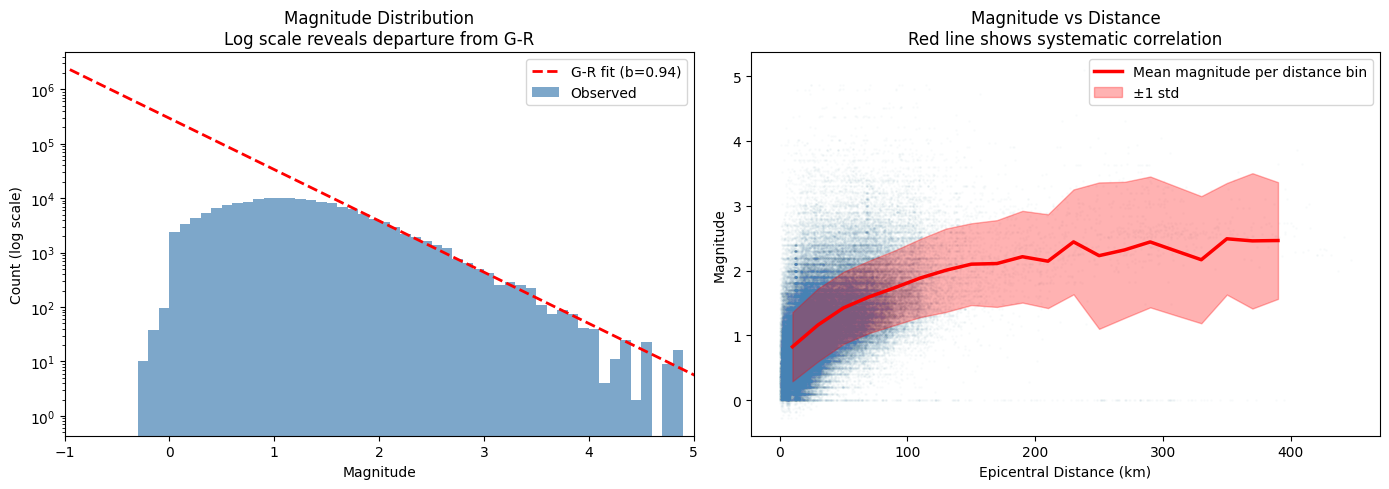


Pearson correlation (distance vs magnitude): 0.501
(A value > 0.3 means the correlation is strong enough
 to be a meaningful bias in your training data)


In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1. Visualise the completeness magnitude more rigorously ─────────────────
# Fit the G-R law to the complete part of the catalog (above Mc)
# and find where the observed distribution departs from it

mag_counts, mag_edges = np.histogram(
    meta['preferred_source_magnitude'].dropna(), 
    bins=np.arange(-1, 6, 0.1)
)
mag_centers = (mag_edges[:-1] + mag_edges[1:]) / 2

# Log-linear fit on the clearly complete part (Ml 1.5 to 4.0)
complete_mask = (mag_centers >= 1.5) & (mag_centers <= 4.0) & (mag_counts > 0)
from scipy import stats
slope_gr, intercept_gr, r_gr, _, _ = stats.linregress(
    mag_centers[complete_mask],
    np.log10(mag_counts[complete_mask] + 1e-10)
)

axes[0].bar(mag_centers, mag_counts, width=0.1, 
            color='steelblue', alpha=0.7, label='Observed')
axes[0].plot(mag_centers,
             10**(slope_gr * mag_centers + intercept_gr),
             'r--', lw=2, label=f'G-R fit (b={-slope_gr:.2f})')
axes[0].set_yscale('log')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Magnitude Distribution\nLog scale reveals departure from G-R')
axes[0].legend()
axes[0].set_xlim(-1, 5)

# Where the observed count falls below G-R fit = completeness magnitude Mc
predicted = 10**(slope_gr * mag_centers + intercept_gr)
ratio = mag_counts / (predicted + 1e-10)
# Mc is roughly where ratio drops below 0.9 (10% deficit)
mc_candidates = mag_centers[(ratio < 0.9) & (mag_centers < 2.0)]
Mc = mc_candidates.max() if len(mc_candidates) > 0 else 1.5
print(f"Estimated completeness magnitude Mc ≈ {Mc:.1f}")
print(f"G-R b-value ≈ {-slope_gr:.2f}  (typical crustal = 0.9–1.1)")

# ── 2. Show the magnitude-distance correlation problem ──────────────────────
# Compute mean magnitude per distance bin
dist_bins = np.arange(0, 420, 20)
meta['dist_bin'] = pd.cut(meta['epi_dist_km'], bins=dist_bins)
mean_mag_by_dist = meta.groupby('dist_bin')['preferred_source_magnitude'].agg(
    ['mean', 'std', 'count']
).reset_index()
mean_mag_by_dist['dist_center'] = [
    interval.mid for interval in mean_mag_by_dist['dist_bin']
]

axes[1].scatter(meta['epi_dist_km'], meta['preferred_source_magnitude'],
                alpha=0.02, s=1, color='steelblue')
axes[1].plot(mean_mag_by_dist['dist_center'],
             mean_mag_by_dist['mean'],
             'r-', lw=2.5, label='Mean magnitude per distance bin')
axes[1].fill_between(
    mean_mag_by_dist['dist_center'],
    mean_mag_by_dist['mean'] - mean_mag_by_dist['std'],
    mean_mag_by_dist['mean'] + mean_mag_by_dist['std'],
    alpha=0.3, color='red', label='±1 std'
)
axes[1].set_xlabel('Epicentral Distance (km)')
axes[1].set_ylabel('Magnitude')
axes[1].set_title('Magnitude vs Distance\nRed line shows systematic correlation')
axes[1].legend()

plt.tight_layout()
plt.savefig('magnitude_analysis.png', dpi=150)
plt.show()

# ── 3. Quantify how bad the magnitude-distance correlation is ───────────────
corr = meta[['epi_dist_km', 'preferred_source_magnitude']].corr()
print(f"\nPearson correlation (distance vs magnitude): "
      f"{corr.loc['epi_dist_km','preferred_source_magnitude']:.3f}")
print("(A value > 0.3 means the correlation is strong enough")
print(" to be a meaningful bias in your training data)")

## 3. SNR Distribution — the most direct quality indicator

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def parse_snr(snr_str):
    """
    Parse 'snr(E)|snr(N)|snr(Z)' string into individual components.
    Returns dict with E, N, Z SNR values and their mean.
    Handles NaN, malformed strings, and missing channels gracefully.
    """
    if pd.isna(snr_str) or snr_str == '':
        return {'snr_E': np.nan, 'snr_N': np.nan, 'snr_Z': np.nan, 'snr_mean': np.nan, 'snr_Z_only': np.nan}
    
    try:
        parts = str(snr_str).split('|')
        vals = [float(p) if p not in ('', 'nan', 'None') else np.nan for p in parts]
        
        # Pad to 3 if missing channels
        while len(vals) < 3:
            vals.append(np.nan)
        
        snr_E, snr_N, snr_Z = vals[0], vals[1], vals[2]
        snr_mean = np.nanmean([snr_E, snr_N, snr_Z])
        
        return {
            'snr_E': snr_E,
            'snr_N': snr_N,
            'snr_Z': snr_Z,
            'snr_mean': snr_mean,
            'snr_Z_only': snr_Z   # Z is most critical for P picking
        }
    except Exception:
        return {'snr_E': np.nan, 'snr_N': np.nan, 'snr_Z': np.nan, 'snr_mean': np.nan, 'snr_Z_only': np.nan}

# Parse and expand into new columns
snr_parsed = meta['trace_snr_db'].apply(parse_snr).apply(pd.Series)
meta = pd.concat([meta, snr_parsed], axis=1)

# Quick sanity check
print(meta[['trace_snr_db', 'snr_E', 'snr_N', 'snr_Z', 'snr_mean']].head(10))
print(f"\nNaN rate per channel:")
for col in ['snr_E', 'snr_N', 'snr_Z']:
    print(f"  {col}: {meta[col].isna().mean():.1%}")

          trace_snr_db   snr_E   snr_N   snr_Z   snr_mean
0   6.135|3.065|11.766   6.135   3.065  11.766   6.988667
1       nan|nan|22.583     NaN     NaN  22.583  22.583000
2    1.756|3.057|3.551   1.756   3.057   3.551   2.788000
3       nan|nan|27.185     NaN     NaN  27.185  27.185000
4  10.881|17.107|2.242  10.881  17.107   2.242  10.076667
5  29.412|30.57|29.827  29.412  30.570  29.827  29.936333
6  14.863|14.12|21.324  14.863  14.120  21.324  16.769000
7    1.175|3.011|5.552   1.175   3.011   5.552   3.246000
8       nan|nan|34.579     NaN     NaN  34.579  34.579000
9       nan|nan|36.606     NaN     NaN  36.606  36.606000

NaN rate per channel:
  snr_E: 28.4%
  snr_N: 28.4%
  snr_Z: 2.0%


Traces with all 3 components : 113,416 / 163,064 (69.6%)
Excluded (missing component) : 49,648

Weakest component breakdown (strict <, complete traces only):
  Z weakest : 64,497  (56.9%)
  E weakest : 24,754  (21.8%)
  N weakest : 24,151  (21.3%)
  Tied      :     14  (0.0%)


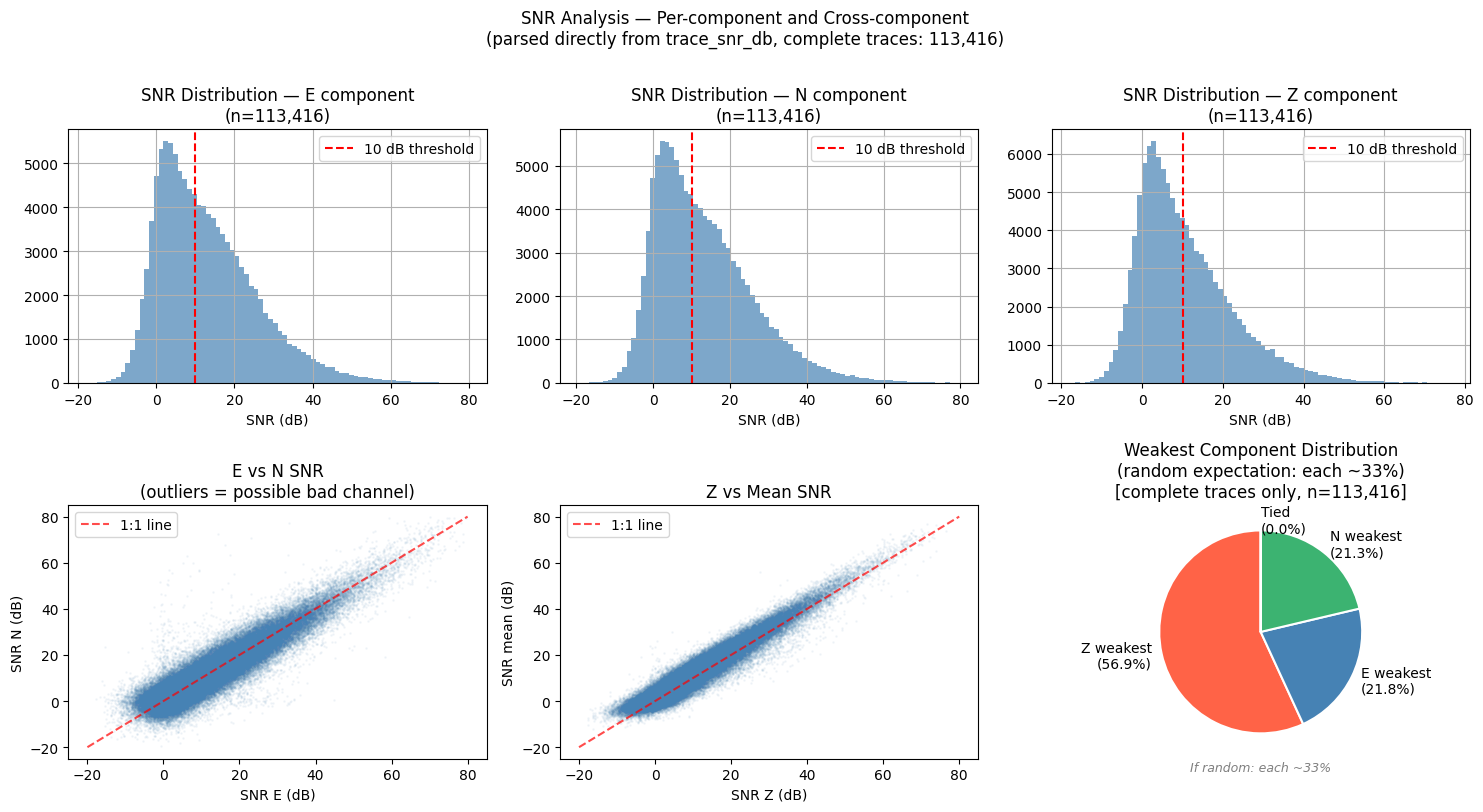

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# ── Parse SNR directly from raw column — single source of truth ──────────────
# Avoids any downstream contamination from earlier parsing steps
snr_split = cat_eq['trace_snr_db'].str.split('|', expand=True)
snr_split.columns = ['snr_E', 'snr_N', 'snr_Z']
snr_split = snr_split.astype(float)

# Only work with traces where all 3 components are present
all_present = snr_split.notna().all(axis=1)
snr_complete = snr_split[all_present].copy()

print(f"Traces with all 3 components : {len(snr_complete):,} "
      f"/ {len(snr_split):,} ({len(snr_complete)/len(snr_split)*100:.1f}%)")
print(f"Excluded (missing component) : {(~all_present).sum():,}")

# ── Compute weakest component — strict < on complete rows only ───────────────
z_weakest = (snr_complete['snr_Z'] < snr_complete['snr_E']) & \
            (snr_complete['snr_Z'] < snr_complete['snr_N'])
e_weakest = (snr_complete['snr_E'] < snr_complete['snr_N']) & \
            (snr_complete['snr_E'] < snr_complete['snr_Z'])
n_weakest = (snr_complete['snr_N'] < snr_complete['snr_E']) & \
            (snr_complete['snr_N'] < snr_complete['snr_Z'])
tied      = ~(z_weakest | e_weakest | n_weakest)

print(f"\nWeakest component breakdown (strict <, complete traces only):")
print(f"  Z weakest : {z_weakest.sum():>6,}  ({z_weakest.mean()*100:.1f}%)")
print(f"  E weakest : {e_weakest.sum():>6,}  ({e_weakest.mean()*100:.1f}%)")
print(f"  N weakest : {n_weakest.sum():>6,}  ({n_weakest.mean()*100:.1f}%)")
print(f"  Tied      : {tied.sum():>6,}  ({tied.mean()*100:.1f}%)")

# ── Also compute mean SNR for the scatter plot ───────────────────────────────
snr_complete['snr_mean'] = snr_complete[['snr_E', 'snr_N', 'snr_Z']].mean(axis=1)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# --- Row 1: Per-component SNR distributions ---------------------------------
for ax, col, label in zip(axes[0],
                           ['snr_E', 'snr_N', 'snr_Z'],
                           ['E', 'N', 'Z']):
    snr_complete[col].hist(bins=80, ax=ax, color='steelblue', alpha=0.7)
    ax.axvline(10, color='r', linestyle='--', label='10 dB threshold')
    ax.set_xlabel('SNR (dB)')
    ax.set_title(f'SNR Distribution — {label} component\n'
                 f'(n={snr_complete[col].notna().sum():,})')
    ax.legend()

# --- Row 2: Cross-component analysis ----------------------------------------

# E vs N SNR
axes[1, 0].scatter(snr_complete['snr_E'], snr_complete['snr_N'],
                   alpha=0.05, s=1, color='steelblue')
axes[1, 0].plot([-20, 80], [-20, 80], 'r--', alpha=0.7, label='1:1 line')
axes[1, 0].set_xlabel('SNR E (dB)')
axes[1, 0].set_ylabel('SNR N (dB)')
axes[1, 0].set_title('E vs N SNR\n(outliers = possible bad channel)')
axes[1, 0].legend()

# Z vs mean SNR
axes[1, 1].scatter(snr_complete['snr_Z'], snr_complete['snr_mean'],
                   alpha=0.05, s=1, color='steelblue')
axes[1, 1].plot([-20, 80], [-20, 80], 'r--', alpha=0.7, label='1:1 line')
axes[1, 1].set_xlabel('SNR Z (dB)')
axes[1, 1].set_ylabel('SNR mean (dB)')
axes[1, 1].set_title('Z vs Mean SNR')
axes[1, 1].legend()

# Corrected pie chart — now shows all 4 categories, not just Z vs not-Z
pie_values = [z_weakest.sum(), e_weakest.sum(),
              n_weakest.sum(), tied.sum()]
pie_labels = [f'Z weakest\n({z_weakest.mean()*100:.1f}%)',
              f'E weakest\n({e_weakest.mean()*100:.1f}%)',
              f'N weakest\n({n_weakest.mean()*100:.1f}%)',
              f'Tied\n({tied.mean()*100:.1f}%)']
pie_colors = ['tomato', 'steelblue', 'mediumseagreen', 'silver']

axes[1, 2].pie(pie_values,
               labels    = pie_labels,
               colors    = pie_colors,
               autopct   = None,        # percentages already in labels
               startangle= 90,
               wedgeprops= dict(edgecolor='white', linewidth=1.5))

# Add reference line annotation
axes[1, 2].set_title('Weakest Component Distribution\n'
                      '(random expectation: each ~33%)\n'
                      f'[complete traces only, n={len(snr_complete):,}]')

# Add a note about what "random" would look like
axes[1, 2].annotate('If random: each ~33%',
                     xy=(0, 0), xycoords='axes fraction',
                     xytext=(0.5, -0.05), textcoords='axes fraction',
                     ha='center', fontsize=9, color='gray',
                     style='italic')

plt.suptitle('SNR Analysis — Per-component and Cross-component\n'
             f'(parsed directly from trace_snr_db, '
             f'complete traces: {len(snr_complete):,})',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('snr_analysis_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

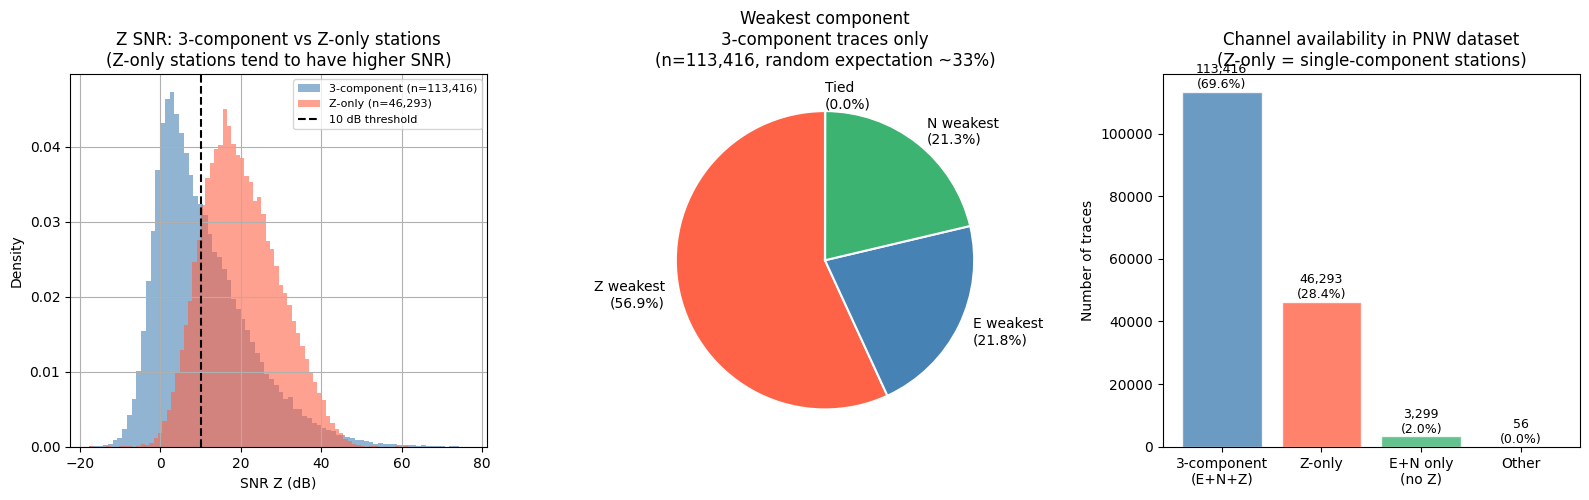

=== Summary for PhaseNet training ===
3-component traces : 113,416 (69.6%)
  → Use for full P+S picking training
  → Among these, Z weakest in 56.9% (vs 33% random)

Z-only traces      : 46,293 (28.4%)
  → PhaseNet requires 3 components → CANNOT use directly
  → Options:
     a) Exclude entirely
     b) Zero-pad E and N channels and train with masking
     c) Use only for Z-channel P-pick pretraining


In [30]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

snr_split = cat_eq['trace_snr_db'].str.split('|', expand=True)
snr_split.columns = ['snr_E', 'snr_N', 'snr_Z']
snr_split = snr_split.astype(float)

has_E = snr_split['snr_E'].notna()
has_N = snr_split['snr_N'].notna()
has_Z = snr_split['snr_Z'].notna()

all_3  = has_E & has_N & has_Z
z_only = ~has_E & ~has_N & has_Z

# ── Panel 1: Z SNR distribution for 3C vs Z-only ────────────────────────────
snr_split.loc[all_3,  'snr_Z'].hist(bins=80, ax=axes[0], alpha=0.6,
                                     color='steelblue', label=f'3-component (n={all_3.sum():,})',
                                     density=True)
snr_split.loc[z_only, 'snr_Z'].hist(bins=80, ax=axes[0], alpha=0.6,
                                     color='tomato', label=f'Z-only (n={z_only.sum():,})',
                                     density=True)
axes[0].axvline(10, color='black', linestyle='--', label='10 dB threshold')
axes[0].set_xlabel('SNR Z (dB)')
axes[0].set_ylabel('Density')
axes[0].set_title('Z SNR: 3-component vs Z-only stations\n'
                  '(Z-only stations tend to have higher SNR)')
axes[0].legend(fontsize=8)

# ── Panel 2: Weakest component — 3C traces only (correct) ───────────────────
snr_3c = snr_split[all_3].copy()

z_w = (snr_3c['snr_Z'] < snr_3c['snr_E']) & (snr_3c['snr_Z'] < snr_3c['snr_N'])
e_w = (snr_3c['snr_E'] < snr_3c['snr_N']) & (snr_3c['snr_E'] < snr_3c['snr_Z'])
n_w = (snr_3c['snr_N'] < snr_3c['snr_E']) & (snr_3c['snr_N'] < snr_3c['snr_Z'])
tied = ~(z_w | e_w | n_w)

axes[1].pie(
    [z_w.sum(), e_w.sum(), n_w.sum(), tied.sum()],
    labels=[f'Z weakest\n({z_w.mean()*100:.1f}%)',
            f'E weakest\n({e_w.mean()*100:.1f}%)',
            f'N weakest\n({n_w.mean()*100:.1f}%)',
            f'Tied\n({tied.mean()*100:.1f}%)'],
    colors=['tomato', 'steelblue', 'mediumseagreen', 'silver'],
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    startangle=90
)
axes[1].set_title(f'Weakest component\n3-component traces only\n'
                  f'(n={all_3.sum():,}, random expectation ~33%)')

# ── Panel 3: Channel availability — the real story ──────────────────────────
categories = ['3-component\n(E+N+Z)', 'Z-only', 'E+N only\n(no Z)', 'Other']
counts     = [all_3.sum(), z_only.sum(),
              (has_E & has_N & ~has_Z).sum(),
              (~all_3 & ~z_only & ~(has_E & has_N & ~has_Z)).sum()]
colors     = ['steelblue', 'tomato', 'mediumseagreen', 'silver']

bars = axes[2].bar(categories, counts, color=colors, alpha=0.8, edgecolor='white')
axes[2].set_ylabel('Number of traces')
axes[2].set_title('Channel availability in PNW dataset\n'
                  '(Z-only = single-component stations)')
for bar, count in zip(bars, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{count:,}\n({count/len(snr_split)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('snr_component_analysis_corrected.png', dpi=150)
plt.show()

# ── Summary for training decisions ──────────────────────────────────────────
print("=== Summary for PhaseNet training ===")
print(f"3-component traces : {all_3.sum():,} ({all_3.mean()*100:.1f}%)")
print(f"  → Use for full P+S picking training")
print(f"  → Among these, Z weakest in {z_w.mean()*100:.1f}% (vs 33% random)")
print()
print(f"Z-only traces      : {z_only.sum():,} ({z_only.mean()*100:.1f}%)")
print(f"  → PhaseNet requires 3 components → CANNOT use directly")
print(f"  → Options:")
print(f"     a) Exclude entirely")
print(f"     b) Zero-pad E and N channels and train with masking")
print(f"     c) Use only for Z-channel P-pick pretraining")

# SNR Analysis: Findings and Implications for PhaseNet Retraining

## Figure 1: Per-component and Cross-component SNR Analysis (3-component traces only, n=113,416)

### 1.1 Per-component SNR Distributions (Top Row)

All three components show a **consistent bimodal structure**:

- A **left mode peaking at ~0–5 dB** — low SNR population near the detection threshold
- A **right mode peaking at ~10–15 dB** — good SNR population with clear arrivals
- A **long right tail to ~80 dB** — strong signals from large or very close events
- The 10 dB threshold falls **between the two modes**, meaning it is a physically 
meaningful separator, not an arbitrary choice

The two populations directly correspond to what was observed in the magnitude distribution:
- Left mode ≈ sub-completeness events (Ml < 1.0), borderline detectable, uncertain picks
- Right mode ≈ catalog-complete events (Ml > 1.0), reliable picks, suitable for training

The Z component distribution is **slightly shifted right** relative to E and N — consistent 
with the Z channel capturing stronger P-wave energy when the SNR window is computed 
around the P arrival.

> **Implication:** A hard SNR threshold applied to the mean of all three components will 
> misclassify many traces. A trace with E=2 dB, N=3 dB, Z=25 dB passes a mean threshold 
> of ~10 dB but has essentially no usable horizontal signal for S picking. 
> **Component-specific thresholds are required.**

---

### 1.2 E vs N SNR Scatter (Bottom Left)

The E and N components show a **very tight, symmetric linear relationship** along the 1:1 
line with no obvious outlier streaks or clusters far off the diagonal.

This is physically expected — both horizontal components record the same S-wave wavefield 
and experience the same broadband noise environment. The symmetric scatter around the 
diagonal reflects normal azimuthal dependence: depending on the source back-azimuth, one 
horizontal always sees slightly more SH or SV energy.

The **absence of horizontal or vertical streaks** is a positive data quality indicator — 
it means there are no systematic bad channels affecting large numbers of stations at the 
catalog level.

> **Implication:** The E and N channels are internally consistent. No bulk station 
> exclusion is needed based on E-N asymmetry alone, though per-station audits are still 
> warranted for individual outliers.

---

### 1.3 Z vs Mean SNR Scatter (Bottom Middle)

The relationship is **extremely tight**, tighter than E vs N, confirming that mean SNR is 
largely driven by Z at low amplitudes and by E/N at high amplitudes:

- At **low SNR**: points lie slightly above the 1:1 line → Z pulls the mean up → Z has 
better P-wave signal than the horizontals for weak events
- At **high SNR**: points lie slightly below the 1:1 line → E/N pull the mean up → 
S-wave energy dominates the horizontals at high amplitudes

> **Implication:** Mean SNR is a reasonable but imperfect scalar summary. For P-pick 
> quality specifically, `snr_Z` is the correct gating criterion. For S-pick quality, 
> `min(snr_E, snr_N)` is more appropriate. Do not use a single mean threshold for both.

---

### 1.4 Weakest Component Pie Chart (Bottom Right)

Among 3-component traces only:

| Component | % weakest | Random expectation |
|-----------|-----------|-------------------|
| Z         | 56.9%     | ~33%              |
| E         | 21.8%     | ~33%              |
| N         | 21.3%     | ~33%              |
| Tied      | 0.0%      | —                 |

Z is the weakest component in **56.9% of 3-component traces** — nearly double the random 
expectation of 33%. E and N are each weakest in only ~21% of traces, well below the 
random expectation of 33%.

This systematic asymmetry is most likely explained by the **SNR window definition** in 
the PNW dataset. If the SNR is computed over the full trace or centered on the S arrival, 
horizontal components will always appear relatively stronger due to the larger S-wave 
energy partition — making Z appear weaker even when the P arrival on Z is perfectly clear.

**This does NOT mean the Z component is unreliable.** It means the SNR metric stored in 
`trace_snr_db` is not a pure measure of P-wave quality on Z. The tight Z vs Mean scatter 
(panel 1.3) confirms Z is not degraded — it simply loses the SNR competition against 
S-dominated horizontals when the full-trace window is used.

> **Implication:** Do **not** use `snr_Z < snr_E` as a flag for bad Z channels. Instead, 
> compute a **P-window-specific SNR** on Z — measuring signal power in the 0–1s *after* 
> the P arrival against noise power in the 2s *before* the P arrival. This gives a direct 
> measure of P-pick reliability on Z, independent of S-wave contamination of the SNR 
> metric.

---

## Figure 2: Channel Availability Analysis

### 2.1 Z SNR: 3-component vs Z-only Stations (Left)

The Z-only stations (red distribution) are **systematically shifted right** compared to 
3-component stations (blue distribution). Z-only stations have a median Z SNR well above 
10 dB, while 3-component stations have a median near or slightly below 10 dB.

This is physically explained by **network deployment history**: Z-only stations in the PNW 
are predominantly older short-period vertical seismometers (EHZ channels) installed at 
sites specifically chosen for low noise — quiet bedrock outcrops, deep vaults, remote 
locations. 3-component broadband stations are more numerous, including noisier sites near 
populated areas.

> **Implication:** Z-only stations are not lower quality — they are actually *higher* 
> quality on Z. But their exclusion from 3-component PhaseNet training is nevertheless 
> necessary because PhaseNet requires all three input channels.

---

### 2.2 Weakest Component — 3-component Traces Only (Middle)

Confirms the 56.9% Z-weakest result from Figure 1. With Z-only stations excluded, the 
systematic SNR asymmetry is even clearer. As argued in section 1.4, this reflects SNR 
window contamination by S-wave energy, not genuine Z channel degradation.

---

### 2.3 Channel Availability in the PNW Dataset (Right)

| Category              | Count   | Percentage |
|-----------------------|---------|------------|
| 3-component (E+N+Z)   | 113,416 | 69.6%      |
| Z-only                |  46,293 | 28.4%      |
| E+N only (no Z)       |   3,299 |  2.0%      |
| Other                 |      56 |  0.0%      |

This is the **most consequential finding** for training. Nearly **30% of the PNW catalog 
is Z-only** and cannot be directly used to train a standard 3-component PhaseNet.

> **Implication:** Before any SNR or pick-quality filtering, the effective training pool 
> is already reduced to **113,416 traces** (69.6% of the full catalog). This is a 
> meaningful but not large dataset for training a deep model from scratch — every 
> subsequent quality filter must be applied carefully to avoid reducing it further than 
> necessary.

---

## Summary of Implications for PhaseNet Retraining

### Dataset size after channel filtering
```python
# Total traces in cat_eq         : 163,064
# Z-only (excluded)              :  46,293  (28.4%)
# E+N only (excluded)            :   3,299   (2.0%)
# Other (excluded)               :      56   (0.0%)
# ─────────────────────────────────────────────────
# Available for 3C PhaseNet      : 113,416  (69.6%)
```

### Recommended component-specific SNR thresholds

Based on the bimodal distributions observed above, the recommended quality thresholds are:
```python
MIN_SNR_Z           = 8.0   # dB — gates P-pick quality on vertical component
MIN_SNR_HORIZONTAL  = 5.0   # dB — at least one of E/N must exceed this for S picking
MAX_SNR_SPREAD      = 20.0  # dB — max(E,N,Z) - min(E,N,Z); flags instrument anomalies
```

Applying these to the 113,416 3-component traces will further reduce the dataset. 
Based on the observed left-mode population (~30–35% of traces below 8 dB on Z), 
expect a final quality-filtered pool of approximately **70,000–85,000 traces** 
before any distance or magnitude balancing.

### Recommended next step

Before finalising the SNR filter, compute the **P-window-specific SNR on Z** directly 
from the waveforms to verify that the stored `snr_Z` metric is a reliable proxy for 
P-pick quality. If the two measures are well-correlated (r > 0.85), the stored metric 
is usable as-is. If they diverge significantly, SNR must be recomputed from the raw 
waveforms before any quality filtering decisions are made.

# 3. Network & Station Biases

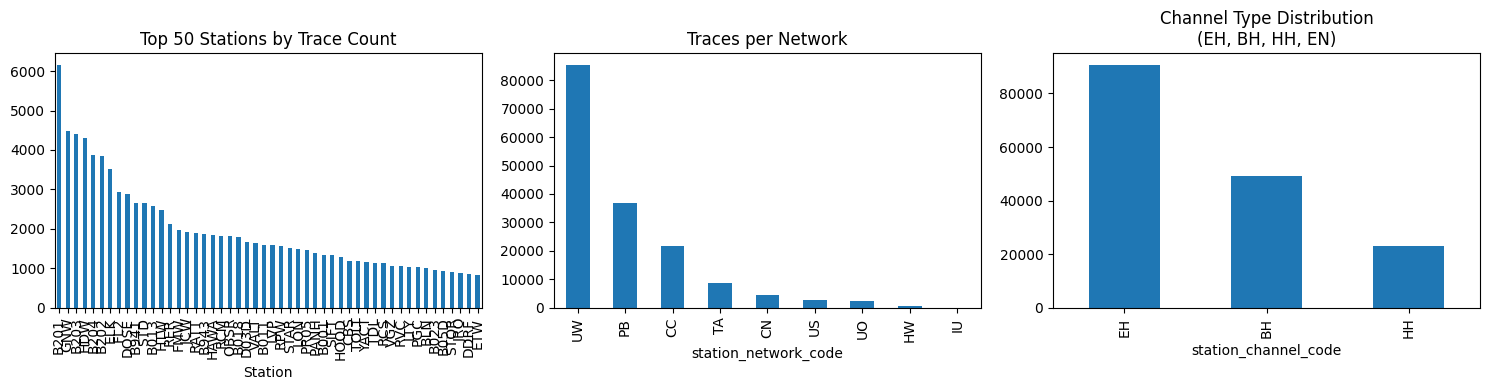

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Traces per station — are a few stations dominating?
station_counts = meta.groupby('station_code').size().sort_values(ascending=False)
station_counts.head(50).plot(kind='bar', ax=axes[0])
axes[0].set_title('Top 50 Stations by Trace Count')
axes[0].set_xlabel('Station')

# Traces per network
meta['station_network_code'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Traces per Network')

# Channel type distribution
meta['station_channel_code'].str[:2].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_title('Channel Type Distribution\n(EH, BH, HH, EN)')
plt.tight_layout()

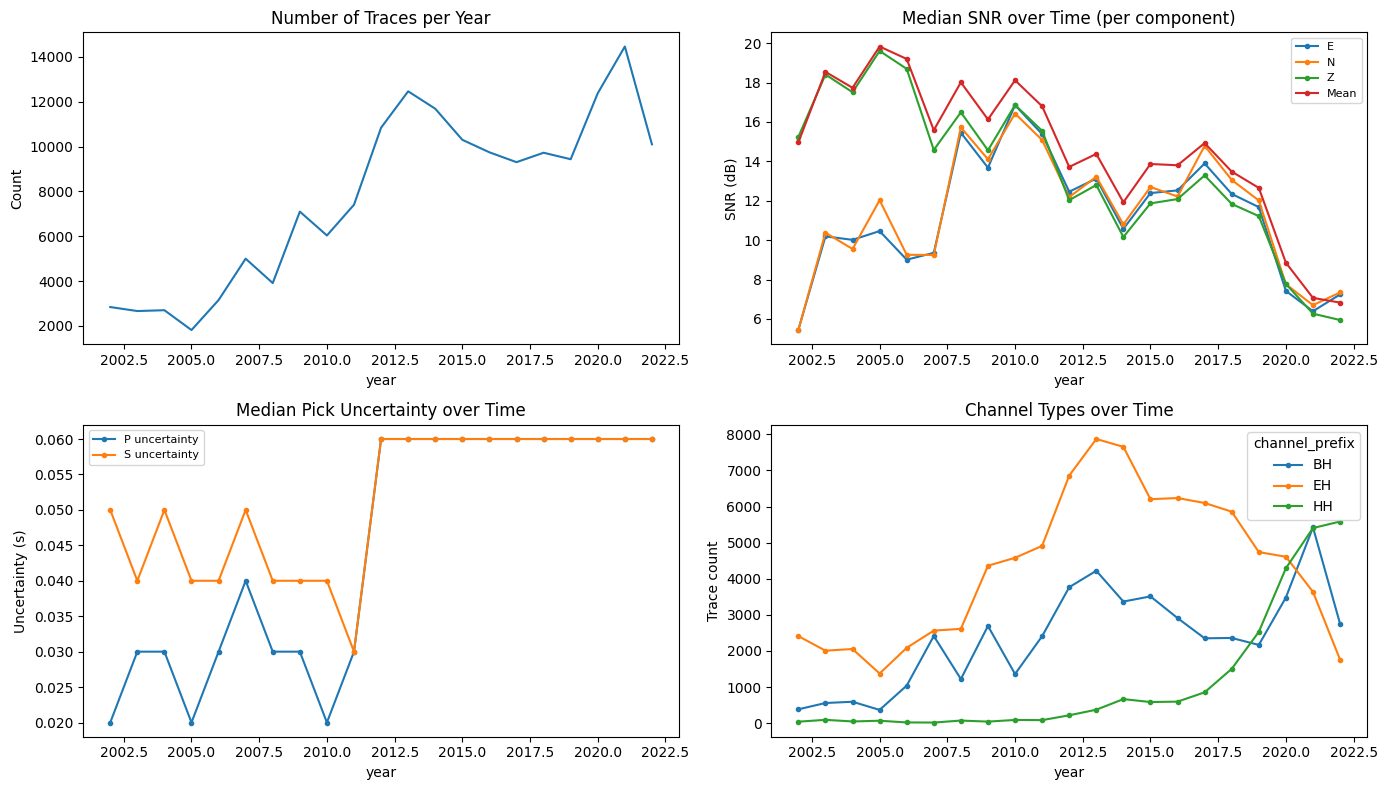

In [10]:
meta['source_origin_time'] = pd.to_datetime(meta['source_origin_time'])
meta['year'] = meta['source_origin_time'].dt.year

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ── Event count over time ────────────────────────────────────────────────────
meta.groupby('year').size().plot(ax=axes[0, 0])
axes[0, 0].set_title('Number of Traces per Year')
axes[0, 0].set_ylabel('Count')

# ── Median SNR over time — now using numeric snr_mean ───────────────────────
# Plot all three components + mean so you can see if one channel degrades
snr_by_year = meta.groupby('year')[['snr_E', 'snr_N', 'snr_Z', 'snr_mean']].median()
snr_by_year.plot(ax=axes[0, 1], marker='o', markersize=3)
axes[0, 1].set_title('Median SNR over Time (per component)')
axes[0, 1].set_ylabel('SNR (dB)')
axes[0, 1].legend(['E', 'N', 'Z', 'Mean'], fontsize=8)

# ── Median P pick uncertainty over time ─────────────────────────────────────
# trace_P_arrival_uncertainty_s might also have non-numeric entries — coerce safely
meta['trace_P_arrival_uncertainty_s'] = pd.to_numeric(
    meta['trace_P_arrival_uncertainty_s'], errors='coerce'
)
meta['trace_S_arrival_uncertainty_s'] = pd.to_numeric(
    meta['trace_S_arrival_uncertainty_s'], errors='coerce'
)

unc_by_year = meta.groupby('year')[
    ['trace_P_arrival_uncertainty_s', 'trace_S_arrival_uncertainty_s']
].median()
unc_by_year.plot(ax=axes[1, 0], marker='o', markersize=3)
axes[1, 0].set_title('Median Pick Uncertainty over Time')
axes[1, 0].set_ylabel('Uncertainty (s)')
axes[1, 0].legend(['P uncertainty', 'S uncertainty'], fontsize=8)

# ── Channel type evolution ───────────────────────────────────────────────────
meta['channel_prefix'] = meta['station_channel_code'].str[:2]
meta.groupby(['year', 'channel_prefix']) \
    .size() \
    .unstack(fill_value=0) \
    .plot(ax=axes[1, 1], marker='o', markersize=3)
axes[1, 1].set_title('Channel Types over Time')
axes[1, 1].set_ylabel('Trace count')

plt.tight_layout()
plt.savefig('temporal_evolution.png', dpi=150)
plt.show()

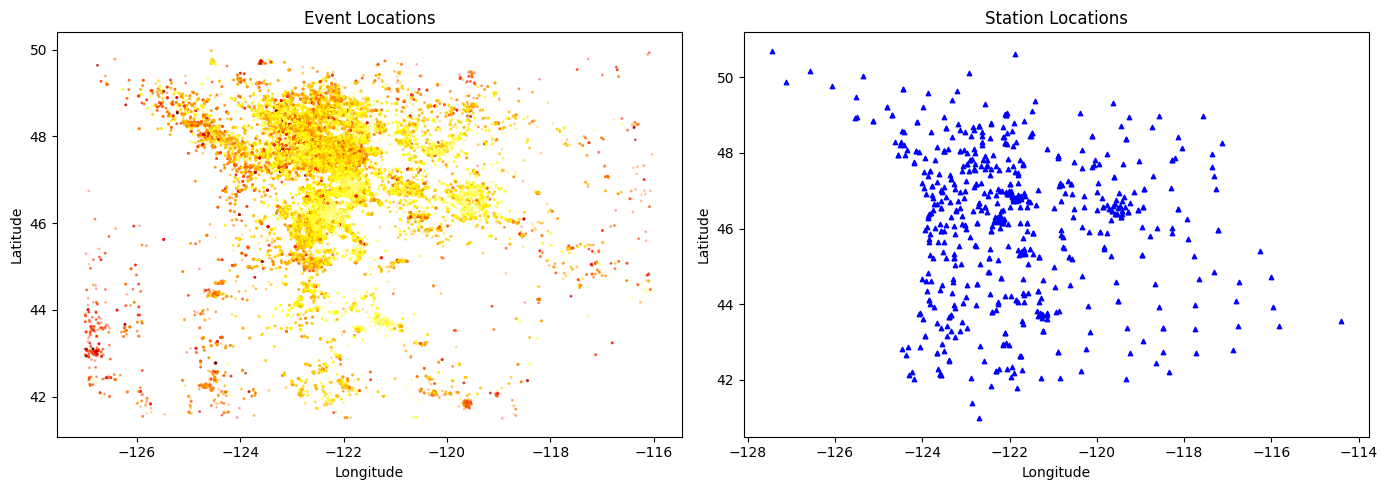

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Event locations
axes[0].scatter(meta['source_longitude_deg'], meta['source_latitude_deg'],
                s=1, alpha=0.3, c=meta['preferred_source_magnitude'], cmap='hot_r')
axes[0].set_title('Event Locations')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Station locations
stations = meta.groupby('station_code').first()
axes[1].scatter(stations['station_longitude_deg'], stations['station_latitude_deg'],
                s=10, marker='^', color='blue')
axes[1].set_title('Station Locations')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.tight_layout()

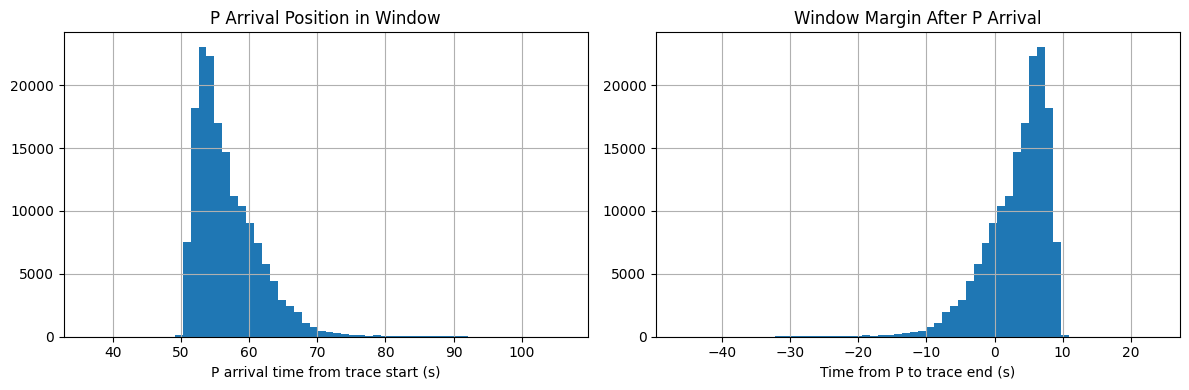

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Where does P fall in the 60-second trace?
meta['p_position_s'] = meta['trace_P_arrival_sample'] / 100.0
meta['s_position_s'] = meta['trace_S_arrival_sample'] / 100.0

meta['p_position_s'].hist(bins=60, ax=axes[0])
axes[0].set_xlabel('P arrival time from trace start (s)')
axes[0].set_title('P Arrival Position in Window')

# P-to-window-end margin
meta['p_to_end_s'] = 60.0 - meta['p_position_s']
meta['p_to_end_s'].hist(bins=60, ax=axes[1])
axes[1].set_xlabel('Time from P to trace end (s)')
axes[1].set_title('Window Margin After P Arrival')
plt.tight_layout()

### Metadata distributions for `cat_eq`

Exploratory histograms (and summary statistics) for earthquake rows in the comcat metadata: **depth**, **magnitude**, **S−P lag** (`trace_S_arrival_sample` − `trace_P_arrival_sample`), **snr_z**, and **snr_min** (minimum of E/N/Z components parsed from `trace_snr_db`).

In [ ]:
# --- Full metadata distributions for cat_eq (earthquake rows only) ---
meta = cat_eq.copy()

# --- Resolve column names (metadata CSV naming can vary slightly) ---
def pick_col(df, substr):
    for c in df.columns:
        if substr.lower() in c.lower():
            return c
    return None

if "source_depth_km" in meta.columns:
    depth_col = "source_depth_km"
else:
    depth_col = pick_col(meta, "depth_km") or pick_col(meta, "depth")

mag_col = pick_col(meta, "magnitude")  # e.g. source_magnitude
p_col = pick_col(meta, "trace_p_arrival_sample") or pick_col(meta, "trace_P_arrival_sample")
s_col = pick_col(meta, "trace_s_arrival_sample") or pick_col(meta, "trace_S_arrival_sample")

# Parse SNR from pipe-separated trace_snr_db: E|N|Z
if "trace_snr_db" in meta.columns:
    snr_split = meta["trace_snr_db"].astype(str).str.split("|", expand=True)
    meta["snr_E"] = pd.to_numeric(snr_split[0], errors="coerce")
    meta["snr_N"] = pd.to_numeric(snr_split[1], errors="coerce")
    meta["snr_z"] = pd.to_numeric(snr_split[2], errors="coerce")
    meta["snr_min"] = meta[["snr_E", "snr_N", "snr_z"]].min(axis=1)
else:
    meta["snr_z"] = np.nan
    meta["snr_min"] = np.nan

# S − P lag in samples (requires both picks)
if p_col and s_col:
    meta["sp_lag_samples"] = pd.to_numeric(meta[s_col], errors="coerce") - pd.to_numeric(meta[p_col], errors="coerce")
else:
    meta["sp_lag_samples"] = np.nan

# --- Build series for plotting (drop NaN per panel) ---
panels = []

if depth_col and depth_col in meta.columns:
    panels.append(("Depth (km)", meta[depth_col], {"xmin": 0}))
else:
    print("Warning: depth column not found")

if mag_col:
    panels.append((f"Magnitude ({mag_col})", meta[mag_col], {}))
else:
    print("Warning: no column containing 'magnitude' found")

if meta["sp_lag_samples"].notna().any():
    panels.append(("S−P lag (samples)", meta["sp_lag_samples"], {"xmin": 0}))

if meta["snr_z"].notna().any():
    panels.append(("snr_z (dB)", meta["snr_z"], {}))

if meta["snr_min"].notna().any():
    panels.append(("snr_min (dB)", meta["snr_min"], {}))

n = len(panels)
if n == 0:
    raise RuntimeError("No plottable columns computed — check cat_eq columns.")

ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()

colors = ["steelblue", "darkorange", "seagreen", "mediumpurple", "coral", "teal"]
for ax, (title, series, kw), color in zip(axes, panels, colors):
    s = pd.to_numeric(series, errors="coerce").dropna()
    ax.hist(s, bins=80, color=color, edgecolor="white", linewidth=0.3, alpha=0.9)
    ax.set_title(title)
    ax.set_ylabel("Count")
    if "xmin" in kw:
        ax.set_xlim(left=kw["xmin"])
    ax.grid(True, alpha=0.3)
    m = s.median()
    ax.axvline(m, color="black", ls="--", lw=1, alpha=0.7)
    ax.text(0.98, 0.95, f"n={len(s):,}\nmedian={m:.3g}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, family="monospace",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

for j in range(len(panels), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("cat_eq metadata distributions", y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

print("Column mapping:")
print(f"  depth: {depth_col!r}" if depth_col and depth_col in meta.columns else "  depth: MISSING")
print(f"  magnitude: {mag_col!r}" if mag_col else "  magnitude: MISSING")
print(f"  P arrival: {p_col!r}" if p_col else "  P arrival: MISSING")
print(f"  S arrival: {s_col!r}" if s_col else "  S arrival: MISSING")
print()
sum_cols = [c for c in [depth_col, mag_col, "sp_lag_samples", "snr_z", "snr_min"] if c and c in meta.columns]
print(meta[sum_cols].describe().to_string())


### Filter high quality picks

- 'trace_has_offset' is a data quality indicator. It indicates if the waveform has a DC shift. It could mean that the signal is not centered on zero or signal has some shift. 

- 'trace_missing_channel' 

In [45]:
df = cat_eq.copy()


snr_split = df['trace_snr_db'].str.split('|', expand=True)

df['snr_E'] = snr_split[0].astype(float)
df['snr_N'] = snr_split[1].astype(float)
df['snr_Z'] = snr_split[2].astype(float)


df['snr_min'] = df[['snr_E','snr_N','snr_Z']].min(axis=1)

df['snr_mean'] = df[['snr_E','snr_N','snr_Z']].mean(axis=1)

df['snr_Z_only'] = df['snr_Z']



df = df[
    (df.trace_P_arrival_sample.notnull()) &
    (df.trace_S_arrival_sample.notnull()) &
    #(df.snr_Z_only > 10) &  # tune threshold
    (~df.trace_has_offset) &
    (~df.trace_missing_channel)
]

### Plot the SNR distribution of SNR

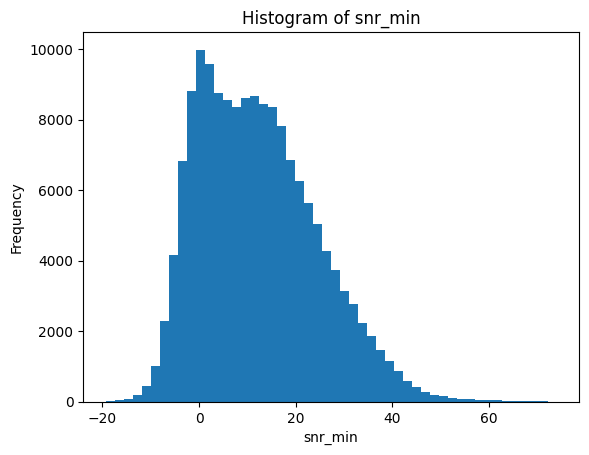

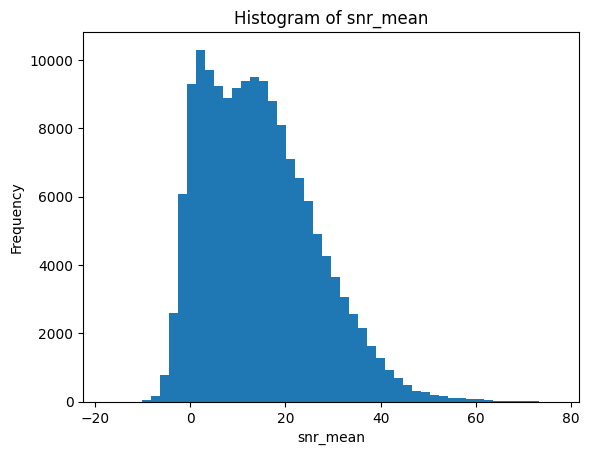

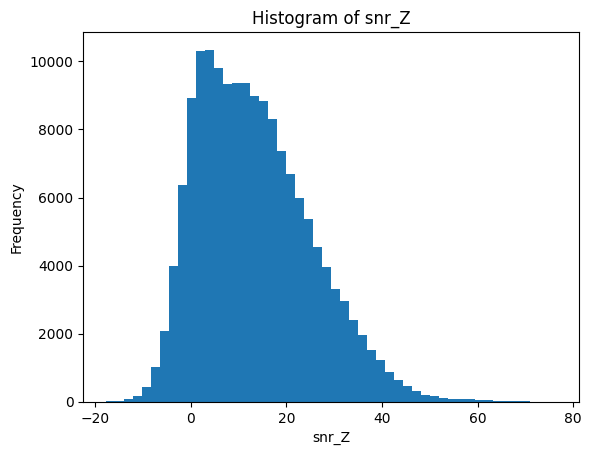

In [46]:
# Plot histograms for snr_min, snr_mean, snr_Z from a DataFrame `df`

# Ensure required columns exist
cols = ['snr_min', 'snr_mean', 'snr_Z']
missing = [c for c in cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in dataframe: {missing}")

# Create separate plots as required
for col in cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Filtering based on SNR

In [47]:
df = df[(df.snr_min > 10)]

### Removing the Station Bias

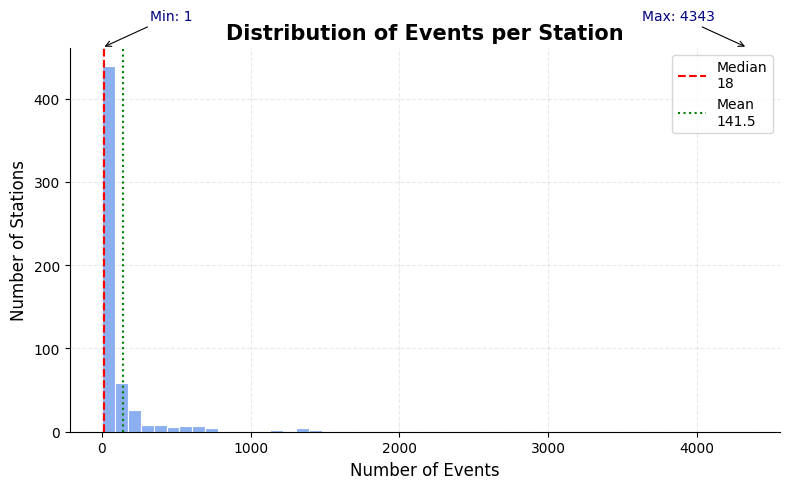

In [ ]:
# Count number of traces/events per station
station_counts = df['station_code'].value_counts()



# Prettified histogram
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(station_counts.values, bins=50, kde=False, color="cornflowerblue", edgecolor="white", ax=ax)

# Show median/mean as vertical lines
median = np.median(station_counts.values)
mean = np.mean(station_counts.values)

ax.axvline(median, color='red', linestyle='dashed', linewidth=1.5, label=f'Median\n{int(median)}')
ax.axvline(mean, color='green', linestyle='dotted', linewidth=1.5, label=f'Mean\n{mean:.1f}')

# Annotate extremes (optional)
max_val = int(station_counts.values.max())
min_val = int(station_counts.values.min())
ax.annotate(f"Max: {max_val}", xy=(max_val, 1), xycoords=('data', 'axes fraction'),
            xytext=(-50,20), textcoords='offset points', arrowprops=dict(arrowstyle='->', lw=0.8),
            fontsize=10, ha='center', color='navy')
ax.annotate(f"Min: {min_val}", xy=(min_val, 1), xycoords=('data', 'axes fraction'),
            xytext=(50,20), textcoords='offset points', arrowprops=dict(arrowstyle='->', lw=0.8),
            fontsize=10, ha='center', color='navy')

ax.set_title("Distribution of Events per Station", fontsize=15, fontweight='bold')
ax.set_xlabel("Number of Events", fontsize=12)
ax.set_ylabel("Number of Stations", fontsize=12)
ax.grid(True, alpha=0.28, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()

In [53]:
K = 1000
df = df.groupby('station_code', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), K), random_state=42)
)

/tmp/ipykernel_2077080/2459579731.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('station_code', group_keys=False).apply(


### Removing the event bias

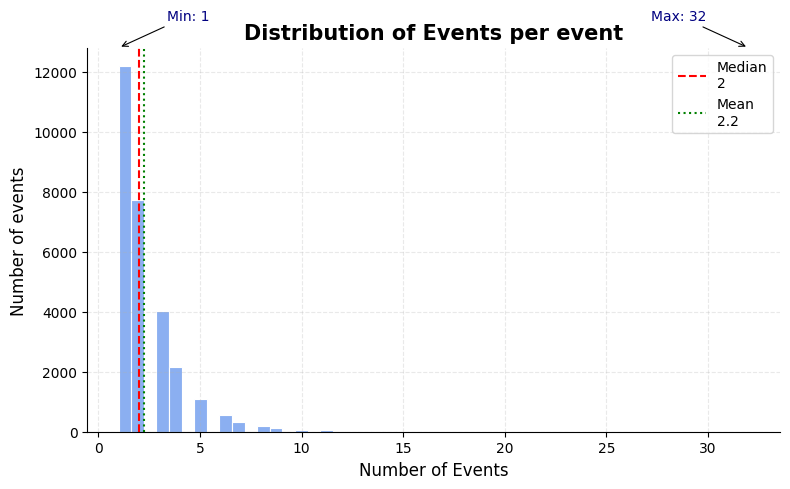

In [55]:
# Count number of traces/events per event
event_counts = df['event_id'].value_counts()



# Prettified histogram
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(event_counts.values, bins=50, kde=False, color="cornflowerblue", edgecolor="white", ax=ax)

# Show median/mean as vertical lines
median = np.median(event_counts.values)
mean = np.mean(event_counts.values)

ax.axvline(median, color='red', linestyle='dashed', linewidth=1.5, label=f'Median\n{int(median)}')
ax.axvline(mean, color='green', linestyle='dotted', linewidth=1.5, label=f'Mean\n{mean:.1f}')

# Annotate extremes (optional)
max_val = int(event_counts.values.max())
min_val = int(event_counts.values.min())
ax.annotate(f"Max: {max_val}", xy=(max_val, 1), xycoords=('data', 'axes fraction'),
            xytext=(-50,20), textcoords='offset points', arrowprops=dict(arrowstyle='->', lw=0.8),
            fontsize=10, ha='center', color='navy')
ax.annotate(f"Min: {min_val}", xy=(min_val, 1), xycoords=('data', 'axes fraction'),
            xytext=(50,20), textcoords='offset points', arrowprops=dict(arrowstyle='->', lw=0.8),
            fontsize=10, ha='center', color='navy')

ax.set_title("Distribution of Events per event", fontsize=15, fontweight='bold')
ax.set_xlabel("Number of Events", fontsize=12)
ax.set_ylabel("Number of events", fontsize=12)
ax.grid(True, alpha=0.28, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()

In [56]:
K = 5
df = df.groupby('event_id', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), K), random_state=42)
)

/tmp/ipykernel_2077080/3559123978.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('event_id', group_keys=False).apply(
